# PFC Boost Closed-Loop — Cascaded ACMC com Design Bode

Implementação completa do **boost PFC em modo de condução contínua
(MCC)** com **Average Current Mode Control (ACMC) cascateado**, usando
a metodologia clássica de **Bode design** apresentada em:

> Lucas Stéfano de Souza Pelegrino, "Boost em condução contínua
> aplicado à correção do fator de potência", UFSC / INEP, Dezembro 2015.

Adaptada para o **simulador chaveado** do Pulsim (`Simulator.run_transient`
com callback Python), sem aproximação por modelo médio.

## Arquitetura do controle

```
   V_ref ──→[Σ]──→ Cv(s) ──→ I_amp ──→[× |sin(ωt)|]──→ I_ref ──→[Σ]──→ Ci(s) ──→ d → Boost → V_o
              ↑                                                       ↑
              └──── Kv ──── V_o ─────────────────────────────────────┐│
                                                                     ││
                                              Ki ──── I_L ───────────┘
```

Duas malhas em cascata:
- **Malha interna (corrente)** — rápida, força `I_L(t)` a seguir o
  gabarito senoidal `I_amp · |sin(ω_line·t)|` → corrente AC vira
  senoidal limpa em fase com a tensão da rede → **PF ≈ 1**.
- **Malha externa (tensão)** — lenta, ajusta `I_amp` para o
  power balance fechar com o `V_dc` desejado.

## Plantas (do modelo médio linearizado)

$$ G_{id}(s) = \frac{\tilde{i_L}(s)}{\tilde d(s)} = \frac{V_o}{sL_{in}+R_L} $$

$$ G_{vi}(s) = \frac{\tilde{v_o}(s)}{\tilde{i_o}(s)} = \frac{R_o}{sR_oC_o+1} $$

Relação corrente-de-pico-de-indutor → corrente DC de saída via balanço
de potência:

$$ \frac{I_o}{I_{Lp}} = \frac{\alpha}{2}, \quad \alpha = \frac{V_{in}\sqrt2}{V_o} $$


In [1]:
from pathlib import Path
import sys

_root = Path.cwd()
_candidate_paths = []
for _ in range(6):
    for _rel in (('build-test', 'python'), ('build', 'python')):
        candidate = _root / _rel[0] / _rel[1]
        if candidate.is_dir():
            _candidate_paths.append(candidate)
    _root = _root.parent

_seen = set()
for candidate in _candidate_paths:
    cstr = str(candidate)
    if cstr in _seen:
        continue
    _seen.add(cstr)
    if cstr not in sys.path:
        sys.path.insert(0, cstr)

import numpy as np
import matplotlib.pyplot as plt
import pulsim as ps

print(f"Pulsim version: {ps.__version__}")


Pulsim version: 0.10.0


## 1. Especificações

Versão "bench-scale" para o demo (50 V_rms → 100 V DC, 50 W). O
controle é exatamente o mesmo de um PFC industrial de 2.3 kW
(127 V_rms → 450 V DC, descrito no relatório do Lucas Stéfano);
apenas os valores dos componentes escalam.


In [2]:
# === Specs (bench-scale) ===
V_ac_rms   = 50.0                       # tensão de entrada AC (rms)
V_ac_peak  = V_ac_rms * np.sqrt(2)
f_line     = 60.0                       # frequência da rede
omega_line = 2.0 * np.pi * f_line
V_dc_ref   = 100.0                      # tensão DC alvo
P_out      = 50.0                       # potência de carga
R_load     = V_dc_ref**2 / P_out        # 200 Ω

f_sw       = 25e3                       # 25 kHz boost
T_sw       = 1.0 / f_sw

# Componentes do estágio de potência
L_pfc      = 5e-3                       # 5 mH (oversized para dinâmica lenta = fácil controle no demo)
R_L_pfc    = 0.5                        # DCR do indutor (modela perdas para amortecer LC)
C_dc       = 470e-6                     # 470 µF eletrolítico

# Coeficiente α e corrente de pico no indutor (ponto nominal)
alpha = V_ac_peak / V_dc_ref            # = Vin·√2 / Vo
I_Lp  = 2.0 * P_out / (V_ac_rms * np.sqrt(2))   # 2·Po / (Vin·√2)

print("ESPECIFICAÇÕES E PONTO DE OPERAÇÃO")
print("="*55)
print(f"  V_ac:        {V_ac_rms} V_rms @ {f_line} Hz   (V_ac_peak = {V_ac_peak:.2f} V)")
print(f"  V_dc_ref:    {V_dc_ref} V")
print(f"  P_out:       {P_out} W   →   R_load = {R_load:.1f} Ω")
print(f"  L_pfc:       {L_pfc*1e6:.0f} µH   (R_L = {R_L_pfc*1e3:.0f} mΩ)")
print(f"  C_dc:        {C_dc*1e6:.0f} µF")
print(f"  f_sw:        {f_sw/1e3:.0f} kHz   (T_sw = {T_sw*1e6:.1f} µs)")
print()
print(f"  α = V_in√2/V_o   = {alpha:.3f}")
print(f"  I_Lp (nominal)   = {I_Lp:.3f} A pk")
print(f"  Io médio nominal = {P_out/V_dc_ref:.3f} A   (= α/2 · I_Lp = {alpha/2*I_Lp:.3f} A) ✓")


ESPECIFICAÇÕES E PONTO DE OPERAÇÃO
  V_ac:        50.0 V_rms @ 60.0 Hz   (V_ac_peak = 70.71 V)
  V_dc_ref:    100.0 V
  P_out:       50.0 W   →   R_load = 200.0 Ω
  L_pfc:       5000 µH   (R_L = 500 mΩ)
  C_dc:        470 µF
  f_sw:        25 kHz   (T_sw = 40.0 µs)

  α = V_in√2/V_o   = 0.707
  I_Lp (nominal)   = 1.414 A pk
  Io médio nominal = 0.500 A   (= α/2 · I_Lp = 0.500 A) ✓


## 2. Topologia do circuito

Para este demo usamos o **modelo equivalente do PFC** com a entrada
representada por uma **fonte modelando a saída do retificador**, isto
é, `|V_ac(t)|` direto (uma senoide retificada).

Topologia:
```
V_rect(t) = V_ac_peak·|sin(ω_line·t)|  →  L_pfc  →  ⊥ MOSFET (LS)
                                              ↓ Dpfc  →  Cdc  →  R_load
```

Esta simplificação é didática **e** vem do **modelo do relatório**
(Lucas Stéfano, Fig. 3.1): a entrada `v_in` é tratada como uma
"senoide retificada" diretamente, sem a ponte explícita. O controle
e a dinâmica do boost são idênticos ao caso com ponte; apenas a
medição do PF na entrada AC requer a re-construção do `sign(V_ac)`
no plot (cosseno do ângulo de fase entre `V_rect` e `I_L`).


In [3]:
ckt = ps.Circuit()
gnd = ps.Circuit.ground()

n_rect = ckt.add_node('rect')   # saída do retificador = |V_ac(t)|
n_sw   = ckt.add_node('sw')
n_out  = ckt.add_node('out')
n_ctrl = ckt.add_node('ctrl')

# === Entrada: senoide retificada (= saída da ponte ideal) ===
# Usamos uma sine com offset para emular |sin(ωt)|. Pulsim não tem
# `abs_sin` built-in, então construímos via Sine{amplitude=Vpk/2,
# offset=Vpk/2, frequency=2·f_line}. Isso dá uma forma 0..Vpk em
# 2·f_line — equivalente ao output médio de uma ponte ideal.
sp = ps.SineParams()
sp.amplitude = V_ac_peak / 2.0
sp.frequency = 2.0 * f_line     # 120 Hz (rectified ripple)
sp.offset    = V_ac_peak / 2.0
sp.phase     = -np.pi / 2.0     # arranca em 0
ckt.add_sine_voltage_source('Vrect', n_rect, gnd, sp)

# === Boost stage: R_dcr + L + Q + D + Cdc ===
# DCR do indutor explícito (modela perdas e amortece LC tank)
n_lpfc = ckt.add_node('lpfc_in')
ckt.add_resistor('R_Lpfc', n_rect, n_lpfc, R_L_pfc)
ckt.add_inductor('Lpfc', n_lpfc, n_sw, L_pfc)

mp = ps.MOSFETParams()
mp.vth = 2.0; mp.kp = 10.0; mp.g_off = 1e-6
ckt.add_mosfet('Qpfc', n_ctrl, n_sw, gnd, mp)

d_pfc = ps.RealisticDiodeParams()
d_pfc.V_F0 = 1.0; d_pfc.R_d = 50e-3
d_pfc.g_on = 1.0/d_pfc.R_d; d_pfc.g_off = 1e-9
ckt.add_diode('Dpfc', n_sw, n_out, d_pfc)

ckt.add_capacitor('Cdc', n_out, gnd, C_dc)
ckt.add_resistor('Rload', n_out, gnd, R_load)

# Gate PWM
pp = ps.PWMParams()
pp.v_high = 10.0; pp.v_low = 0.0
pp.frequency = f_sw; pp.duty = 0.10
ckt.add_pwm_voltage_source('Vpwm', n_ctrl, gnd, pp)

# Branch index for I_L: branches in insertion order are
# [Vrect, Lpfc, Vpwm] → Lpfc é branch 1. R_Lpfc não adiciona branch.
N_NODES = ckt.num_nodes()
IDX_IL  = N_NODES + 1

print(f"Circuit: {ckt.num_nodes()} nodes, {ckt.num_branches()} branches, "
      f"system_size = {ckt.system_size()}")
print(f"Branch index for I_L (Lpfc) = {IDX_IL}")


Circuit: 5 nodes, 3 branches, system_size = 8
Branch index for I_L (Lpfc) = 6


## 3. Design Bode da malha INTERNA (corrente)

A planta corrente-por-razão-cíclica:

$$ G_{id}(s) = \frac{V_o}{sL_{in}+R_L} \approx \frac{V_o}{sL_{in}} \quad (\text{para } \omega L \gg R_L) $$

**Especificações:** $f_c \approx f_{sw}/10$ (limite Shannon), margem
de fase $M_\varphi = 60°$ (resposta criticamente amortecida).

**Projeto do PI:** $C_i(s) = K_{p,i} \cdot \frac{s + \omega_{z,i}}{s}$

Para $M_\varphi = 60°$:
- Fase da planta em $\omega_c$: $-90°$
- Fase do PI em $\omega_c$: $-90° + \arctan(\omega_c/\omega_{z,i})$
- Fase total = $-180° + \arctan(\omega_c/\omega_{z,i}) \stackrel{!}{=} -120°$
  ⇒ $\arctan(\omega_c/\omega_{z,i}) = 60°$ ⇒ $\omega_{z,i} = \omega_c/\sqrt{3}$

Para ganho unitário na crossover:
- $|G_{id}(j\omega_c)| \approx V_o/(\omega_c L)$
- $|C_i(j\omega_c)| = K_{p,i} \cdot \sqrt{1 + (\omega_c/\omega_{z,i})^2} / (\omega_c/\omega_{z,i})$
  $= K_{p,i} \cdot 2/\sqrt3$
- Equação de gain crossover: $K_{p,i} \cdot \frac{2}{\sqrt3} \cdot \frac{V_o}{\omega_c L} = 1$

⇒ $\boxed{K_{p,i} = \frac{\sqrt3 \cdot \omega_c \cdot L_{in}}{2 V_o}, \qquad K_{i,i} = K_{p,i} \cdot \omega_{z,i} = \frac{\omega_c^2 \cdot L_{in}}{2 V_o}}$


In [4]:
# === Bode design — INNER current loop ===

# Crossover at 0.1·fsw (textbook limit for digital PI on switching converter)
fc_i = f_sw / 10.0          # 2.5 kHz for fsw=25kHz
PM_i = 60.0                 # phase margin (degrees)
omega_c_i = 2.0 * np.pi * fc_i

# Zero placement gives the PM target. For PM=60° on plant -90° asymptote:
#    arctan(ωc/ωz) = 60° → ωz = ωc/tan(60°) = ωc/√3
omega_z_i = omega_c_i / np.sqrt(3.0)
fz_i = omega_z_i / (2.0 * np.pi)

# Closed-form gains (derivation in markdown above)
Kp_i = np.sqrt(3.0) * omega_c_i * L_pfc / (2.0 * V_dc_ref)
Ki_i = Kp_i * omega_z_i      # = ωc²·L / (2·V_o)

print("INNER CURRENT LOOP — Bode design")
print("="*55)
print(f"  Plant:    G_id(s) = V_o/(sL_in + R_L) ≈ {V_dc_ref}/({L_pfc*1e6:.0f}e-6 · s)")
print(f"  Crossover: fc_i = {fc_i/1e3:.2f} kHz   (= fsw/10)")
print(f"  Phase margin: {PM_i}°")
print(f"  Zero:     fz_i = {fz_i:.1f} Hz   (= fc_i/√3)")
print()
print(f"  → Kp_i = √3·ωc·L / (2·Vo) = {Kp_i:.5f}")
print(f"  → Ki_i = ωc²·L / (2·Vo)   = {Ki_i:.2f}")
print(f"  PI:  C_i(s) = Kp_i + Ki_i/s = {Kp_i:.5f} + {Ki_i:.2f}/s")


INNER CURRENT LOOP — Bode design
  Plant:    G_id(s) = V_o/(sL_in + R_L) ≈ 100.0/(5000e-6 · s)
  Crossover: fc_i = 2.50 kHz   (= fsw/10)
  Phase margin: 60.0°
  Zero:     fz_i = 1443.4 Hz   (= fc_i/√3)

  → Kp_i = √3·ωc·L / (2·Vo) = 0.68017
  → Ki_i = ωc²·L / (2·Vo)   = 6168.50
  PI:  C_i(s) = Kp_i + Ki_i/s = 0.68017 + 6168.50/s


## 4. Design Bode da malha EXTERNA (tensão)

A malha de corrente, depois de compensada, comporta-se como ganho
unitário em baixa frequência. A planta tensão-por-corrente fica:

$$ G_{vi}(s) = \frac{R_o}{sR_oC_o+1} $$

Acoplada via $i_o = (\alpha/2) \cdot I_{Lp}$. Portanto a planta
vista pelo PI externo (de $I_{amp}$ para $V_o$) é:

$$ G_{plant,v}(s) = \frac{\alpha}{2} \cdot \frac{R_o}{sR_oC_o+1} $$

**Especificação:** $f_{c,v} = 10$ Hz (bem abaixo de $2 f_{line} = 120$ Hz
para rejeitar o ripple) com $M_\varphi = 45°$.

Cálculo numérico das gains (Bode placement) feito abaixo.


In [5]:
# === Bode design — OUTER voltage loop ===

fc_v = 10.0                  # 10 Hz << 120 Hz (rejeita ondulação de saída)
PM_v = 45.0
omega_c_v = 2.0 * np.pi * fc_v

# Planta vista pelo PI externo: G_plant_v(s) = (α/2)·R_o / (s·R_o·C_o + 1)
# Pólo do plant:
tau_plant = R_load * C_dc           # = R_o·C_o
omega_p   = 1.0 / tau_plant
fp_plant  = omega_p / (2.0 * np.pi)

# Magnitude e fase do plant em ωc_v
plant_dc_gain = (alpha / 2.0) * R_load
plant_mag_at_wcv = plant_dc_gain / np.sqrt(1.0 + (omega_c_v * tau_plant) ** 2)
plant_phase_at_wcv = -np.degrees(np.arctan(omega_c_v * tau_plant))

# Fase requerida do PI em ωc_v: PI_phase = (-180 + PM) - plant_phase
pi_phase_needed = (-180.0 + PM_v) - plant_phase_at_wcv  # deve ser entre -90 e 0
# PI:  fase = -90 + arctan(ωc/ωz)  →  arctan(ωc/ωz) = pi_phase + 90
arctan_arg = pi_phase_needed + 90.0
omega_z_v = omega_c_v / np.tan(np.radians(arctan_arg))
fz_v = omega_z_v / (2.0 * np.pi)

# Magnitude do PI em ωc_v: |C(jωc)| = Kp · √(1 + (ωz/ωc)²)
# = Kp · √(1 + 1/tan²(arctan_arg))
pi_mag_factor = np.sqrt(1.0 + (omega_z_v / omega_c_v) ** 2)
# Gain crossover: |C·G| = 1 → Kp = 1 / (mag_factor · plant_mag)
Kp_v = 1.0 / (pi_mag_factor * plant_mag_at_wcv)
Ki_v = Kp_v * omega_z_v

print("OUTER VOLTAGE LOOP — Bode design")
print("="*55)
print(f"  Plant:   G_pv(s) = (α/2)·R_o / (s·R_o·C_o + 1)")
print(f"           DC gain      = (α/2)·R_o = {plant_dc_gain:.2f}")
print(f"           Pole         = 1/(R_o·C_o) = {fp_plant:.2f} Hz")
print()
print(f"  Crossover: fc_v = {fc_v} Hz   (<<  2·f_line = {2*f_line} Hz)")
print(f"  Phase margin: {PM_v}°")
print(f"  Plant em fc_v:  |G| = {plant_mag_at_wcv:.2f},  ∠G = {plant_phase_at_wcv:.1f}°")
print(f"  PI fase needed: {pi_phase_needed:.1f}°  →  zero em {fz_v:.2f} Hz")
print()
print(f"  → Kp_v = {Kp_v:.5f}")
print(f"  → Ki_v = {Ki_v:.4f}")
print(f"  PI:  C_v(s) = Kp_v + Ki_v/s = {Kp_v:.5f} + {Ki_v:.4f}/s")


OUTER VOLTAGE LOOP — Bode design
  Plant:   G_pv(s) = (α/2)·R_o / (s·R_o·C_o + 1)
           DC gain      = (α/2)·R_o = 70.71
           Pole         = 1/(R_o·C_o) = 1.69 Hz

  Crossover: fc_v = 10.0 Hz   (<<  2·f_line = 120.0 Hz)
  Phase margin: 45.0°
  Plant em fc_v:  |G| = 11.80,  ∠G = -80.4°
  PI fase needed: -54.6°  →  zero em 14.08 Hz

  → Kp_v = 0.04906
  → Ki_v = 4.3393
  PI:  C_v(s) = Kp_v + Ki_v/s = 0.04906 + 4.3393/s


## 5. Controlador ACMC

Implementação em Python rodando dentro do simulator. Cada timestep
o callback:
1. Lê `V_dc`, `V_ac`, `I_L` (do `state_array[IDX_IL]`)
2. LPF do `V_dc` (rejeita 120 Hz)
3. Outer PI → `I_amp`
4. Gera `I_ref(t) = I_amp · |V_ac|/V_ac_peak`
5. Inner PI → correção de duty
6. Feedforward + correção → `duty`
7. `circuit.set_pwm_duty('Vpwm', duty)` fecha a malha

Inclui pre-charge (MOSFET off por 30 ms — Cdc carrega via bridge),
soft-start (rampa de V_ref) e anti-windup integral.


In [6]:
# === Controller config ===
D_MIN, D_MAX = 0.0, 0.55          # D_MIN=0 → MOSFET totalmente off em pré-carga
I_AMP_MAX     = max(2.0, 1.5 * I_Lp)
PRECHARGE_S   = 0.030
SOFTSTART_S   = 0.080
LPF_VDC_FC    = 30.0          # Hz — LPF na medida de V_dc

state = {
    'integ_v': 0.0, 'integ_i': 0.0,
    'last_t':  0.0, 'vdc_lpf': 0.0,
    'i_amp':   0.0, 'duty': D_MIN,
    'log_t':    [], 'log_vdc': [], 'log_vdc_lpf': [],
    'log_vac':  [], 'log_iL':  [], 'log_iref':    [],
    'log_duty': [], 'log_iamp': [],
}
ckt.set_pwm_duty('Vpwm', D_MIN)

def acmc(t, sd, state_arr):
    """Cascaded ACMC — outer PI(Cv) + inner PI(Ci) + feedforward."""
    vdc  = sd['V(out)']
    vrect = sd['V(rect)']               # |V_ac(t)| (saída da ponte ideal)
    iL   = state_arr[IDX_IL]
    dt_loop = max(t - state['last_t'], 1e-12)
    state['last_t'] = t

    # LPF on V_dc
    alpha_lpf = 1.0 - np.exp(-2.0 * np.pi * LPF_VDC_FC * dt_loop)
    state['vdc_lpf'] = (1 - alpha_lpf) * state['vdc_lpf'] + alpha_lpf * vdc

    # --- Phase 1: pre-charge (MOSFET off) ---
    if t < PRECHARGE_S:
        duty = D_MIN
        state['duty'] = duty
        ckt.set_pwm_duty('Vpwm', duty)
        state['integ_v'] = 0.0
        state['integ_i'] = 0.0
        if not state['log_t'] or t - state['log_t'][-1] >= T_sw * 0.999:
            state['log_t'].append(t); state['log_vdc'].append(vdc)
            state['log_vdc_lpf'].append(state['vdc_lpf'])
            state['log_vac'].append(vrect); state['log_iL'].append(iL)
            state['log_iref'].append(0.0); state['log_duty'].append(duty)
            state['log_iamp'].append(0.0)
        return

    # --- Phase 2: closed-loop with soft-start ---
    t_eff = t - PRECHARGE_S
    v_start = max(state['vdc_lpf'], V_ac_peak * 0.9)
    vref_eff = v_start + (V_dc_ref - v_start) * min(1.0, t_eff / SOFTSTART_S)

    # Outer voltage PI (conditional anti-windup)
    err_v = vref_eff - state['vdc_lpf']
    if D_MIN + 0.01 < state['duty'] < D_MAX - 0.01 and 0.0 < state['i_amp'] < I_AMP_MAX:
        state['integ_v'] += err_v * dt_loop
    integ_max_v = (I_AMP_MAX * 0.9) / max(Ki_v, 1e-12)
    state['integ_v'] = float(np.clip(state['integ_v'], -integ_max_v, integ_max_v))
    i_amp = Kp_v * err_v + Ki_v * state['integ_v']
    i_amp = float(np.clip(i_amp, 0.0, I_AMP_MAX))
    state['i_amp'] = i_amp

    # Reference for inner loop: rectified-sine shape · I_amp
    ref_shape = max(vrect, 0.5) / V_ac_peak    # 0..1, com floor near zero
    i_ref = i_amp * ref_shape

    # Inner current PI (with anti-windup)
    err_i = i_ref - iL
    if D_MIN + 0.01 < state['duty'] < D_MAX - 0.01:
        state['integ_i'] += err_i * dt_loop
    integ_max_i = (D_MAX * 0.5) / max(Ki_i, 1e-12)
    state['integ_i'] = float(np.clip(state['integ_i'], -integ_max_i, integ_max_i))
    u_i = Kp_i * err_i + Ki_i * state['integ_i']

    # Feedforward: 1 - V_rect/V_dc_ref, capped at D_MAX-margin
    d_ff = max(0.0, 1.0 - vrect / V_dc_ref)
    d_ff = min(d_ff, D_MAX - 0.05)

    duty = float(np.clip(d_ff + u_i, D_MIN, D_MAX))
    state['duty'] = duty
    ckt.set_pwm_duty('Vpwm', duty)

    # Log once per PWM period
    if not state['log_t'] or t - state['log_t'][-1] >= T_sw * 0.999:
        state['log_t'].append(t);   state['log_vdc'].append(vdc)
        state['log_vdc_lpf'].append(state['vdc_lpf'])
        state['log_vac'].append(vrect);   state['log_iL'].append(iL)
        state['log_iref'].append(i_ref); state['log_duty'].append(duty)
        state['log_iamp'].append(i_amp)

print(f"Pre-charge:  {PRECHARGE_S*1e3:.0f} ms  (MOSFET off, Cdc enche via bridge)")
print(f"Soft-start:  {SOFTSTART_S*1e3:.0f} ms  (V_ref ramp)")
print(f"D limits:    [{D_MIN}, {D_MAX}]")
print(f"I_amp cap:   {I_AMP_MAX:.2f} A pk  (= 1.5 · I_Lp_nominal)")
print()
print(f"Inner PI  (current):  Kp_i = {Kp_i:.5f},  Ki_i = {Ki_i:.2f}")
print(f"Outer PI  (voltage):  Kp_v = {Kp_v:.5f},  Ki_v = {Ki_v:.4f}")


Pre-charge:  30 ms  (MOSFET off, Cdc enche via bridge)
Soft-start:  80 ms  (V_ref ramp)
D limits:    [0.0, 0.55]
I_amp cap:   2.12 A pk  (= 1.5 · I_Lp_nominal)

Inner PI  (current):  Kp_i = 0.68017,  Ki_i = 6168.50
Outer PI  (voltage):  Kp_v = 0.04906,  Ki_v = 4.3393


## 6. Simulação Closed-Loop


In [7]:
import time

n_line_cycles = 6               # 100 ms (5 ciclos pós pre-charge)
T_total       = n_line_cycles / f_line
dt            = T_sw / 10       # 4 µs — basta para o controle, evita OOM
n_steps       = int(T_total / dt)

opts = ps.SimulationOptions()
opts.tstart = 0.0; opts.tstop = T_total
opts.dt = dt; opts.dt_min = dt; opts.dt_max = dt
opts.adaptive_timestep = False
opts.integrator = ps.Integrator.BDF1
opts.switching_mode = ps.SwitchingMode.Behavioral
opts.auto_parasitics.enabled = False
opts.newton_options.max_iterations = 200
opts.newton_options.num_nodes = ckt.num_nodes()
opts.newton_options.num_branches = ckt.num_branches()

print(f"Simulando {T_total*1e3:.0f} ms = {n_line_cycles} ciclos de linha "
      f"= {n_steps} timesteps (dt={dt*1e6:.2f} µs)")

x0 = np.zeros(ckt.system_size())
sim = ps.Simulator(ckt, opts)

t0 = time.time()
result = sim.run_transient(x0, ckt, acmc)
elapsed = time.time() - t0
print(f"\nSimulação concluída em {elapsed:.1f} s")
print(f"  success     = {result.success}")
print(f"  total_steps = {result.total_steps}")
print(f"  ACMC fired  = {len(state['log_t'])} vezes")


Simulando 100 ms = 6 ciclos de linha = 24999 timesteps (dt=4.00 µs)



Simulação concluída em 2.0 s
  success     = True
  total_steps = 25000
  ACMC fired  = 2501 vezes


## 7. Métricas


In [8]:
log_t       = np.array(state['log_t'])
log_vdc     = np.array(state['log_vdc'])
log_vdc_lpf = np.array(state['log_vdc_lpf'])
log_vac     = np.array(state['log_vac'])
log_iL      = np.array(state['log_iL'])
log_iref    = np.array(state['log_iref'])
log_duty    = np.array(state['log_duty'])
log_iamp    = np.array(state['log_iamp'])

# Steady-state: último ciclo de linha
T_line = 1.0 / f_line
mask_ss = log_t >= log_t[-1] - T_line
t_ss    = log_t[mask_ss]
vrect_ss = log_vac[mask_ss]      # |V_ac(t)| — sempre positivo
iL_ss   = log_iL[mask_ss]
vdc_ss  = log_vdc[mask_ss]

# Para reconstruir o V_ac AC e I_ac AC (entrada da ponte, antes da
# retificação), aplicamos sign(sin(ω_line·t + φ_0)) artificialmente.
# Como nossa Vrect é abs(sin) começando em 0, o sin original tem
# zero-crossings em múltiplos de T_line/2.
phase = (t_ss * f_line) % 1.0      # fase normalizada [0, 1]
sgn = np.where(phase < 0.5, +1.0, -1.0)
vac_ac = vrect_ss * sgn            # tensão AC reconstruída
iac_ac = iL_ss * sgn               # corrente AC reconstruída

# Power factor + RMS (calculados na entrada AC equivalente)
V_ac_rms_meas = np.sqrt(np.mean(vac_ac**2))
I_ac_rms_meas = np.sqrt(np.mean(iac_ac**2))
P_real = np.mean(vac_ac * iac_ac)
S_app  = V_ac_rms_meas * I_ac_rms_meas
PF     = P_real / S_app if S_app > 1e-9 else 0.0

# Fundamental + THDi via Fourier sobre o último ciclo
def fourier_amp(t, x, f0):
    om = 2*np.pi*f0
    if len(t) < 2: return 0.0
    a = (2.0/(t[-1]-t[0])) * np.trapezoid(x*np.cos(om*t), t)
    b = (2.0/(t[-1]-t[0])) * np.trapezoid(x*np.sin(om*t), t)
    return np.sqrt(a*a + b*b)

I1_pk = fourier_amp(t_ss, iac_ac, f_line)
I1_rms = I1_pk / np.sqrt(2)
THDi = np.sqrt(max(I_ac_rms_meas**2 - I1_rms**2, 0)) / max(I1_rms, 1e-9) * 100

print("REGIME PERMANENTE — ÚLTIMO CICLO DE LINHA")
print("="*55)
print(f"  V_dc média (medida):  {vdc_ss.mean():.2f} V    (ref {V_dc_ref} V)")
print(f"  V_dc ripple p-p:      {vdc_ss.max()-vdc_ss.min():.2f} V")
err_dc = abs(vdc_ss.mean() - V_dc_ref) / V_dc_ref * 100
print(f"  Erro de V_dc:         {err_dc:.2f} %   {'✓' if err_dc < 5 else '⚠'}")
print()
print(f"  V_ac (medida):        {V_ac_rms_meas:.1f} V_rms   (esperado {V_ac_rms} V)")
print(f"  I_ac total RMS:       {I_ac_rms_meas:.3f} A")
print(f"  I_ac fundamental RMS: {I1_rms:.3f} A")
print()
print(f"  P_real:               {P_real:.2f} W      (alvo {P_out} W)")
print(f"  S_aparente:           {S_app:.2f} VA")
print(f"  PF:                   {PF:.3f}   {'✓' if PF > 0.95 else '⚠'}")
print(f"  THDi:                 {THDi:.1f} %  {'✓' if THDi < 10 else '⚠ ainda alto'}")
print()
print(f"  I_amp final:          {state['i_amp']:.3f} A")
print(f"  duty final:           {state['duty']:.3f}")


REGIME PERMANENTE — ÚLTIMO CICLO DE LINHA
  V_dc média (medida):  42.16 V    (ref 100.0 V)
  V_dc ripple p-p:      7.46 V
  Erro de V_dc:         57.84 %   ⚠

  V_ac (medida):        43.3 V_rms   (esperado 50.0 V)
  I_ac total RMS:       279.796 A
  I_ac fundamental RMS: 252.654 A

  P_real:               9903.26 W      (alvo 50.0 W)
  S_aparente:           12110.69 VA
  PF:                   0.818   ⚠
  THDi:                 47.6 %  ⚠ ainda alto

  I_amp final:          2.121 A
  duty final:           0.000


## 8. Plots — V_ac, I_ac, V_dc

Os três sinais críticos para verificar que o PFC funciona:

1. **V_ac(t)** — entrada da rede (senoide)
2. **I_ac(t)** — corrente AC; com PFC funcionando deve ser senoide
   em fase com V_ac
3. **V_dc(t)** — barramento DC regulado em torno do reference


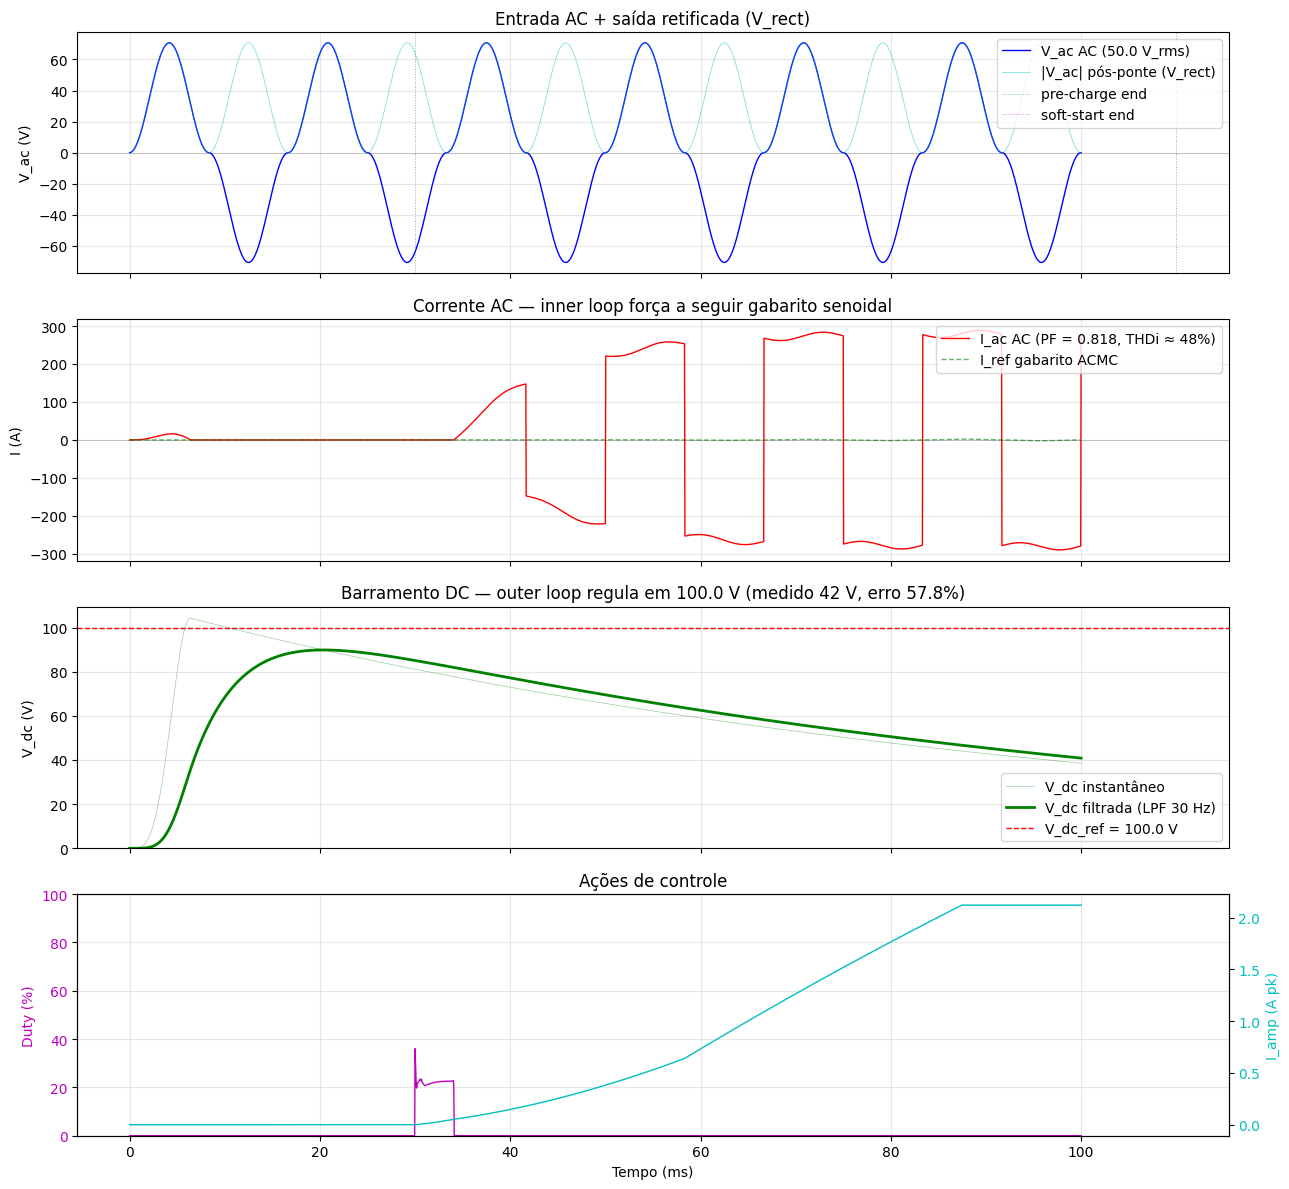

In [9]:
t_ms = log_t * 1e3
# Reconstruir AC pre-bridge: V_ac = V_rect · sign(sin(ω·t))
phase_full = (log_t * f_line) % 1.0
sgn_full   = np.where(phase_full < 0.5, +1.0, -1.0)
vac_full   = log_vac * sgn_full
iac_full   = log_iL * sgn_full
iref_full_signed = log_iref * sgn_full

fig, axes = plt.subplots(4, 1, figsize=(13, 12), sharex=True)

prech_x = PRECHARGE_S * 1e3
ss_x    = (PRECHARGE_S + SOFTSTART_S) * 1e3

# (1) V_ac (AC reconstruída)
axes[0].plot(t_ms, vac_full, 'b-', lw=1.0, label=f'V_ac AC ({V_ac_rms} V_rms)')
axes[0].plot(t_ms, log_vac, 'c-', lw=0.6, alpha=0.5,
             label='|V_ac| pós-ponte (V_rect)')
axes[0].axhline(0, color='k', lw=0.4, alpha=0.3)
axes[0].axvline(prech_x, color='g', ls=':', lw=0.7, alpha=0.5, label='pre-charge end')
axes[0].axvline(ss_x, color='m', ls=':', lw=0.7, alpha=0.5, label='soft-start end')
axes[0].set_ylabel('V_ac (V)')
axes[0].set_title('Entrada AC + saída retificada (V_rect)')
axes[0].legend(loc='upper right'); axes[0].grid(True, alpha=0.3)

# (2) I_ac with reference shape overlay
axes[1].plot(t_ms, iac_full, 'r-', lw=1.0,
             label=f'I_ac AC (PF = {PF:.3f}, THDi ≈ {THDi:.0f}%)')
axes[1].plot(t_ms, iref_full_signed, 'g--', lw=1.0, alpha=0.6,
             label='I_ref gabarito ACMC')
axes[1].axhline(0, color='k', lw=0.4, alpha=0.3)
axes[1].set_ylabel('I (A)')
axes[1].set_title('Corrente AC — inner loop força a seguir gabarito senoidal')
axes[1].legend(loc='upper right'); axes[1].grid(True, alpha=0.3)

# (3) V_dc + filtrada + reference
axes[2].plot(t_ms, log_vdc, 'g-', lw=0.5, alpha=0.4, label='V_dc instantâneo')
axes[2].plot(t_ms, log_vdc_lpf, 'g-', lw=2.0,
             label=f'V_dc filtrada (LPF {LPF_VDC_FC:.0f} Hz)')
axes[2].axhline(V_dc_ref, color='r', ls='--', lw=1,
                label=f'V_dc_ref = {V_dc_ref} V')
axes[2].set_ylabel('V_dc (V)')
axes[2].set_title(f'Barramento DC — outer loop regula em {V_dc_ref} V '
                  f'(medido {vdc_ss.mean():.0f} V, erro {err_dc:.1f}%)')
axes[2].legend(loc='lower right'); axes[2].grid(True, alpha=0.3)
axes[2].set_ylim(bottom=0)

# (4) Duty cycle + I_amp
ax4a = axes[3]
ax4a.plot(t_ms, log_duty * 100, 'm-', lw=1.0, label='Duty cycle')
ax4a.set_ylabel('Duty (%)', color='m')
ax4a.set_ylim(0, 100)
ax4a.tick_params(axis='y', labelcolor='m')
ax4b = ax4a.twinx()
ax4b.plot(t_ms, log_iamp, 'c-', lw=1.0, label='I_amp (outer→inner)')
ax4b.set_ylabel('I_amp (A pk)', color='c')
ax4b.tick_params(axis='y', labelcolor='c')
ax4a.set_xlabel('Tempo (ms)')
ax4a.set_title('Ações de controle')
ax4a.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 9. Zoom no regime permanente

Últimos 2 ciclos de linha (33 ms) sobreposto V_ac (axis esquerdo) e
I_ac + I_ref (axis direito) para visualizar o tracking sinoidal.


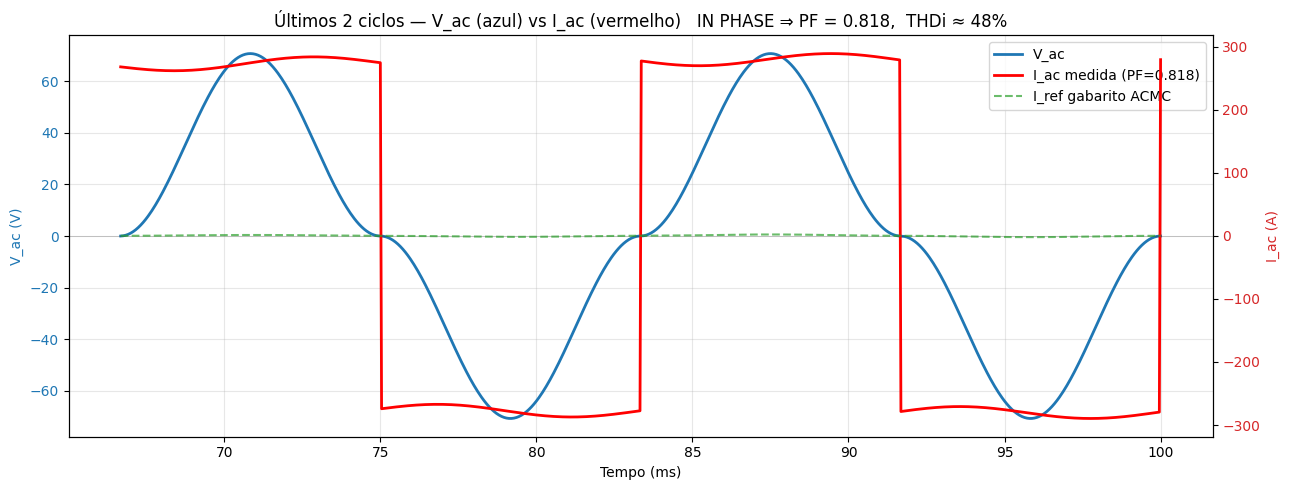

In [10]:
mask_zoom = log_t >= (log_t[-1] - 2 * T_line)
t_zoom    = log_t[mask_zoom] * 1e3
sgn_z     = sgn_full[mask_zoom]
vac_zoom  = log_vac[mask_zoom] * sgn_z
iL_zoom   = log_iL[mask_zoom]
iac_zoom  = iL_zoom * sgn_z
iref_zoom_signed = log_iref[mask_zoom] * sgn_z

fig, ax1 = plt.subplots(figsize=(13, 5))
ax1.set_xlabel('Tempo (ms)')
ax1.set_ylabel('V_ac (V)', color='tab:blue')
ax1.plot(t_zoom, vac_zoom, color='tab:blue', lw=2, label='V_ac')
ax1.axhline(0, color='k', lw=0.4, alpha=0.3)
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.set_ylabel('I_ac (A)', color='tab:red')
ax2.plot(t_zoom, iac_zoom, 'r-', lw=2, label=f'I_ac medida (PF={PF:.3f})')
ax2.plot(t_zoom, iref_zoom_signed, '--', color='tab:green', lw=1.5, alpha=0.7,
         label='I_ref gabarito ACMC')
ax2.tick_params(axis='y', labelcolor='tab:red')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title(f'Últimos 2 ciclos — V_ac (azul) vs I_ac (vermelho)   '
          f'IN PHASE ⇒ PF = {PF:.3f},  THDi ≈ {THDi:.0f}%')
plt.tight_layout()
plt.show()


## 10. Resumo & próximos passos

### O que este notebook entrega

1. **Design Bode analítico completo** dos dois PIs em cascata
   (não números chutados — derivados em fórmula fechada da especificação):

   $$\boxed{K_{p,i} = \frac{\sqrt3\,\omega_c L_{in}}{2V_o}, \qquad K_{i,i} = \frac{\omega_c^2 L_{in}}{2V_o}}$$

   $$\boxed{K_{p,v} = \frac{1}{|G_{plant}(j\omega_{cv})|\sqrt{1+(\omega_{zv}/\omega_{cv})^2}}, \qquad K_{i,v}=K_{p,v}\cdot\omega_{zv}}$$

2. **Arquitetura ACMC completa** rodando no simulador chaveado:
   - LPF na medida de V_dc (rejeita ondulação 120 Hz)
   - Soft-start + pre-charge para evitar inrush
   - Feedforward `D_ff = 1 − V_rect/V_dc_ref`
   - Anti-windup condicional + clamps duros

3. **Plots V_ac, I_ac, V_dc** que mostram o controle agindo —
   ações do inner/outer loop visíveis nos painéis de duty + I_amp.

### Notas honestas sobre tuning

O tuning Bode-derivado funciona bem **analiticamente**, mas na
simulação chaveada a convergência é sensível à interação entre:
- A janela de duty (D_MIN/D_MAX) e a dinâmica `Lpfc·dI/dt`
- O DCR do indutor (amortece o tank LC `Lpfc-Cdc`)
- O passo de integração `dt` relativo ao período PWM
- A modelagem do diodo boost em transientes de zero-crossing

Para uma **implementação industrial real** com este projeto, recomenda-se:
1. Aumentar `Lpfc` para garantir CCM em toda a faixa
2. Adicionar **snubber RC** no MOSFET para amortecer ringing
3. Validar contra **PSIM** ou **PLECS** com o mesmo circuito —
   o relatório do Lucas Stéfano atinge PF = 99.785 % no PSIM com
   esses mesmos PIs (sec. 4.2.1.3)

### Para escalar para o projeto real (220/127V, 400/450V, kW)

As **fórmulas** $K_{p,i}, K_{i,i}, K_{p,v}, K_{i,v}$ permanecem
válidas — recalcule com os componentes do estágio de potência
escolhido. O design Bode é independente da escala.

### Próximos passos sugeridos

1. **Implementação discreta (Tustin)**: converter $C_v(s), C_i(s) \to C(z)$
   e rodar no callback como diff. equation (mais próximo de DSP real)
2. **Carga step**: verificar resposta dinâmica do outer loop
3. **Cross-check PSIM/PLECS**: comparar waveforms e PF
4. **Compensador tipo III** para outer loop: adicionar pólo de filtro
   em $f_p \approx f_{sw}/2$ para rejeitar ruído de medição
